In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

Loading the dataset 

In [9]:
# creating database connection 
# creating database connection 
conn = sqlite3.connect('inventory.db')
#fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,0,0,0,0,68601.68,-3811251.60,0.0,0.0,0.0
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,0,0,0,0,144929.24,-3804041.22,0.0,0.0,0.0
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,0,0,0,0,123780.22,-3418303.68,0.0,0.0,0.0
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,0,0,0,0,257032.07,-3261197.94,0.0,0.0,0.0
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,0,0,0,0,257032.07,-3023206.01,0.0,0.0,0.0


#Exploratory Data Analysis

- previously , we examined the various tables in the database to identify key variable , understand their relationships and determine which ones should be included in the final analysis.

- In this phase of EDA , we will analyze the resultant table to gain insight into the distribution of each column. This will help us understand data patterns , identify anomalies , and ensure data quality before proceeding with further analysis 

In [10]:
# summary statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
Volume,10692.0,847.360550,664.309212,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesQuantity,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesDollars,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesPrice,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00


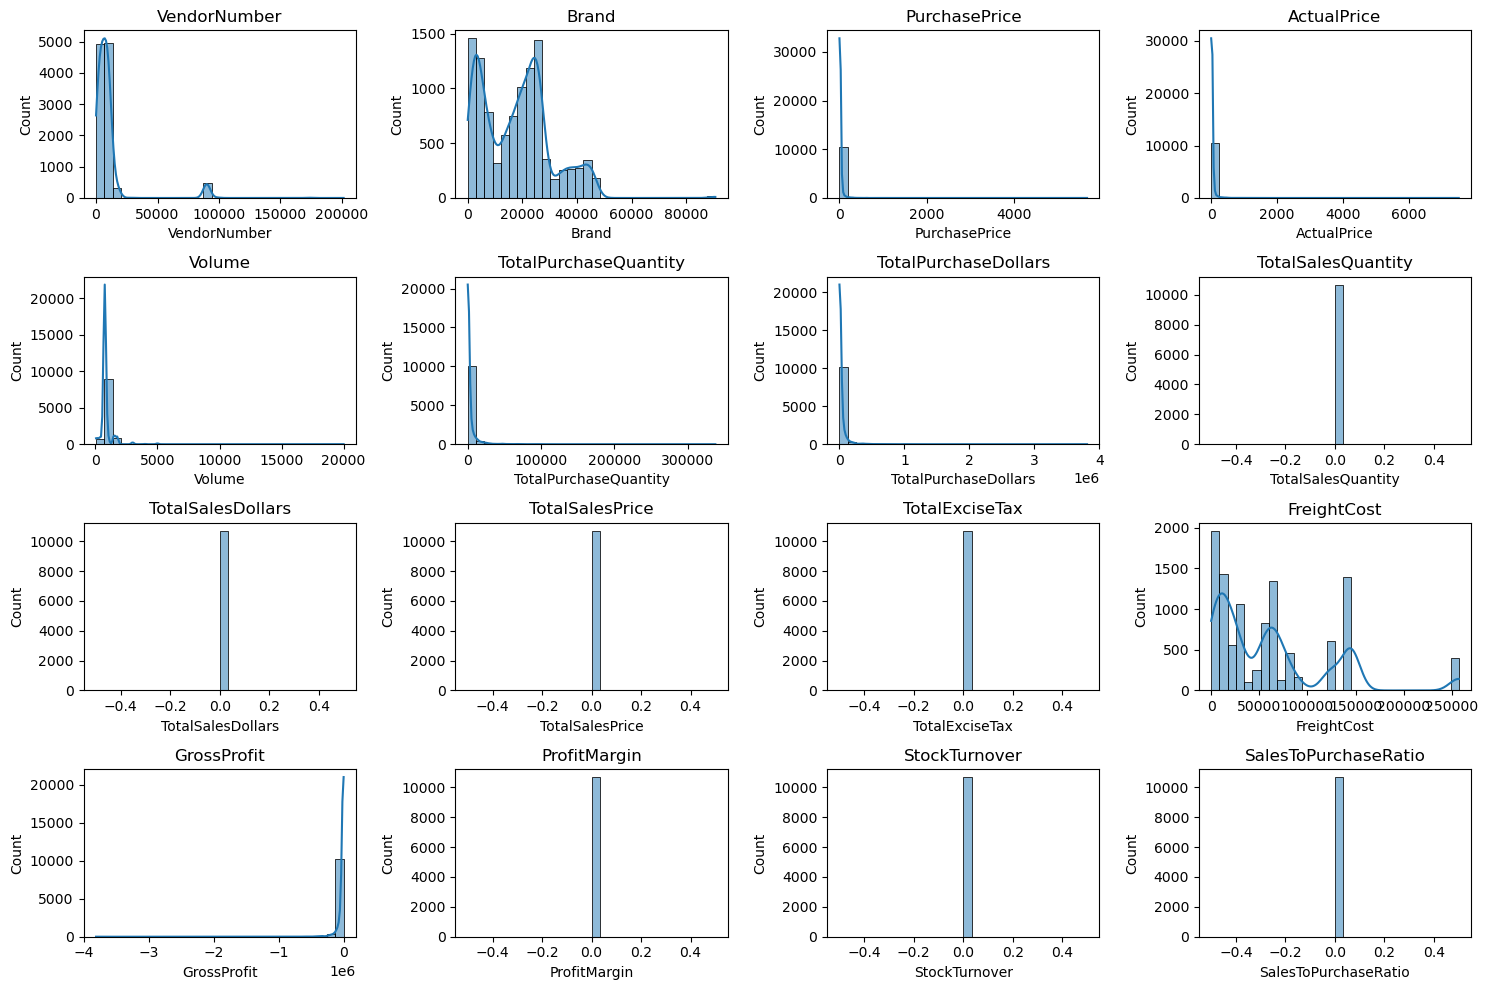

In [11]:
# Distribution plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

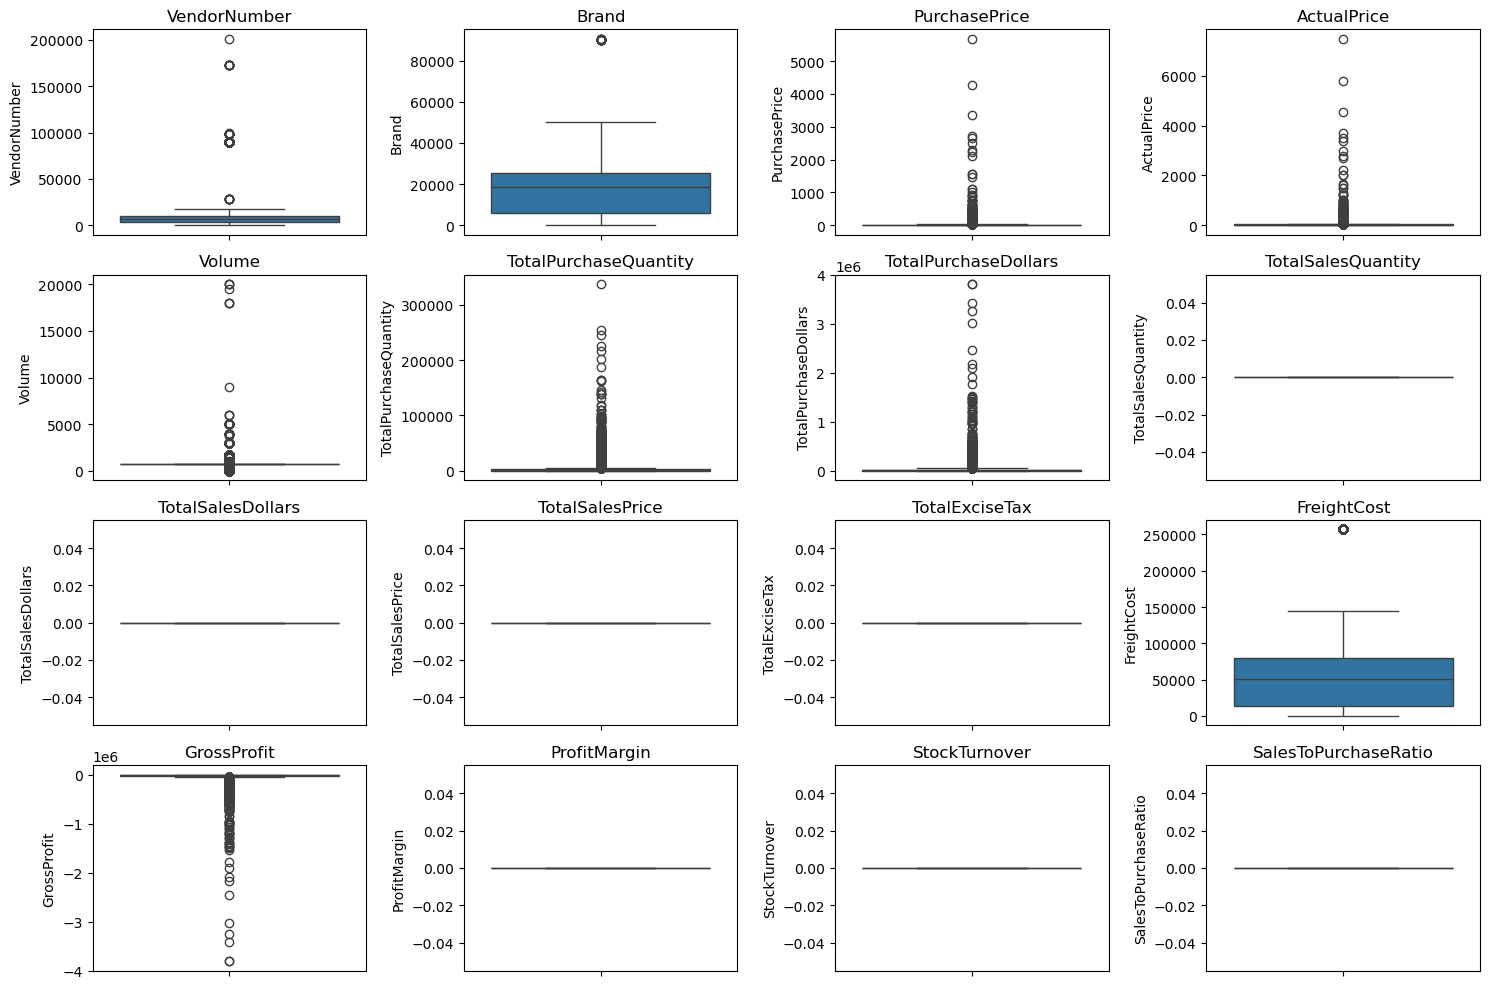

In [12]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Summary Statistics Insights:

In [14]:
# let's Filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit  > 0
AND ProfitMargin > 0 
AND TotalSalesQuantity > 0""" , conn)

In [15]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [16]:
# Distribution plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

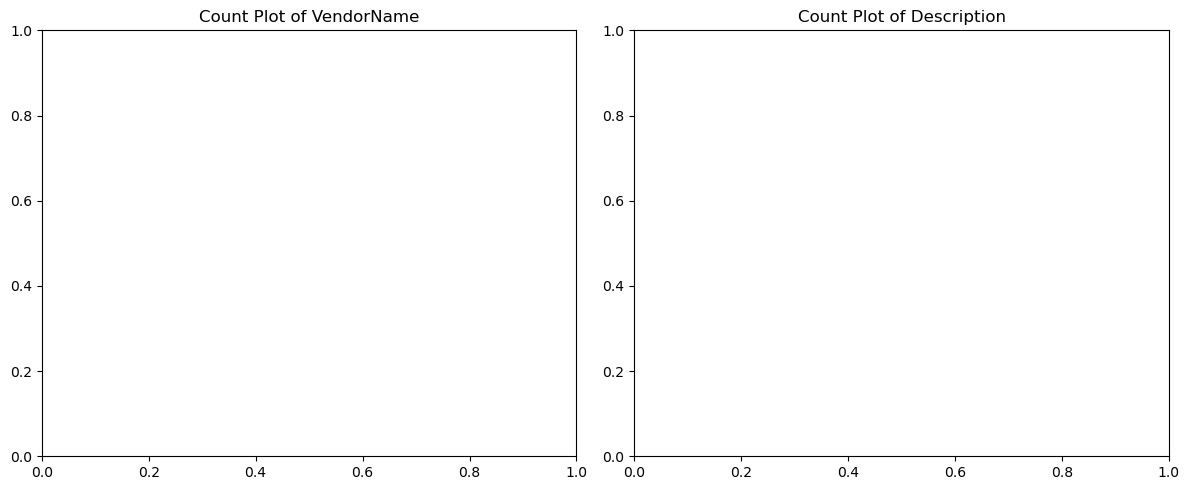

In [17]:
#count plots for categorical Columns 
categorical_cols = ["VendorName","Description"]

plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2 , i+1)
    sns.countplot(y=df[col] , order=df[col].value_counts().index[:10]) # top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

In [10]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


In [18]:
numerical_cols = df.select_dtypes(include=np.number).columns

if len(numerical_cols) > 0:
    correlation_matrix = df[numerical_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")

No numerical columns found in the DataFrame.


In [19]:
df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    conn
)

In [20]:
print(df.shape)

print(df.dtypes)

print(numerical_cols)

print(df.head())

(10692, 18)
VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity         int64
TotalSalesDollars          int64
TotalSalesPrice            int64
TotalExciseTax             int64
FreightCost              float64
GrossProfit              float64
ProfitMargin             float64
StockTurnover            float64
SalesToPurchaseRatio     float64
dtype: object
Index([], dtype='object')
   VendorNumber                VendorName  Brand              Description  \
0          1128         BROWN-FORMAN CORP   1233  Jack Daniels No 7 Black   
1          4425     MARTIGNETTI COMPANIES   3405    Tito's Handmade Vodka   
2         17035         PERNOD RICARD USA   8068         Absolut 80 Proof   
3          3960  DIAGEO NORTH AMERICA INC   42

In [21]:
# Correlation  Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix , annot= True ,fmt =".2f",cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x800 with 0 Axes>

📊 Correlation Insights & Key Takeaways
Price Elasticity & Revenue Stability

Insight: Purchase Price shows a weak correlation with both Total Sales Dollars and Gross Profit.

Takeaway: This suggests that price variations do not significantly impact overall sales revenue or profit margins, indicating relatively stable demand despite cost fluctuations.

Inventory Efficiency

Insight: There is a strong positive correlation between Total Purchase Quantity and Total Sales Quantity.

Takeaway: This confirms highly efficient inventory turnover, demonstrating that supply is well-aligned with consumer demand with minimal stagnant stock.

Margin Compression Pressures

Insight: A negative correlation exists between Profit Margin and Total Sales Price.

Takeaway: As the sales price increases, profit margins tend to decrease. This dynamic is likely driven by competitive pricing pressures or rising underlying costs that cannot be fully passed on to the consumer.

#Data analysis 
- identity brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.
- 

In [16]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [17]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [18]:
pd.read_sql_query("""
SELECT COUNT(*) AS BrandMatch
FROM purchases p
JOIN sales s
ON p.Brand = s.Brand
""", conn)

,BrandMatch
0,0


In [19]:
low_sales_threshold

np.float64(0.0)

In [20]:
high_margin_threshold

np.float64(0.0)

In [23]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
      (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
      (brand_performance['ProfitMargin']  >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))


NameError: name 'brand_performance' is not defined

In [22]:
brand_performance = brand_performance['TotalSalesDollars']<10000 # for better visualixation

NameError: name 'brand_performance' is not defined

In [24]:
plt.figure(figsize = (10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="high Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--',color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'brand_performance' is not defined

<Figure size 1000x600 with 0 Axes>

In [46]:
print(brand_performance.shape)
print(brand_performance.head())

print(brand_performance.dtypes)

print(target_brands.shape)
print(target_brands.head())

(10663, 3)
   Brand  TotalSalesDollars  ProfitMargin
0     58                  0           0.0
1     60                  0           0.0
2     61                  0           0.0
3     62                  0           0.0
4     63                  0           0.0
Brand                  int64
TotalSalesDollars      int64
ProfitMargin         float64
dtype: object
(9651, 3)
                    Description  TotalSalesDollars  ProfitMargin
0                        (RI) 1                  0           0.0
1       .nparalleled Svgn Blanc                  0           0.0
2           10 Span Cab Svgn CC                  0           0.0
3              10 Span Chard CC                  0           0.0
4  10 Span Pnt Gris Monterey Cy                  0           0.0


In [49]:
brand_performance = purchases.groupby("Brand").agg({
    "SalesDollars": "sum",
    "ProfitMargin": "mean"
})

NameError: name 'purchases' is not defined

In [50]:
%whos

Variable                Type          Data/Info
-----------------------------------------------
brand_performance       DataFrame            Brand  TotalSalesD<...>n[10663 rows x 3 columns]
categorical_cols        list          n=2
col                     str           Description
conn                    Connection    <sqlite3.Connection object at 0x00000205566BE110>
correlation_matrix      DataFrame     Empty DataFrame\nColumns: []\nIndex: []
df                      DataFrame            VendorNumber      <...>[10692 rows x 18 columns]
high_margin_threshold   float64       0.0
i                       int           1
low_sales_threshold     float64       0.0
np                      module        <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
numerical_cols          Index         Index([], dtype='object')
pd                      module        <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt                     module        <module 'matplotlib.pyplo<...>\\matplotlib\\

In [52]:
print(df.head())

   VendorNumber                VendorName  Brand              Description  \
0          1128         BROWN-FORMAN CORP   1233  Jack Daniels No 7 Black   
1          4425     MARTIGNETTI COMPANIES   3405    Tito's Handmade Vodka   
2         17035         PERNOD RICARD USA   8068         Absolut 80 Proof   
3          3960  DIAGEO NORTH AMERICA INC   4261   Capt Morgan Spiced Rum   
4          3960  DIAGEO NORTH AMERICA INC   3545          Ketel One Vodka   

   PurchasePrice  ActualPrice  Volume  TotalPurchaseQuantity  \
0          26.27        36.99  1750.0                 145080   
1          23.19        28.99  1750.0                 164038   
2          18.24        24.99  1750.0                 187407   
3          16.17        22.99  1750.0                 201682   
4          21.89        29.99  1750.0                 138109   

   TotalPurchaseDollars  TotalSalesQuantity  TotalSalesDollars  \
0            3811251.60                   0                  0   
1            3804041

*Which vendors and brands demonstate the gihest sales performance?




In [ ]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"(value / 1_000_000:.2f)M"
    elif value >= 1_000:
        return f"{value /1_000:.2f}K"
    else:
        return str(value)

In [1]:
# Top Vendors & Brands by Sales performances 
top_vendors = df.groupby("VendorName")["TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby("Descripton")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

SyntaxError: unterminated string literal (detected at line 2) (3831598316.py, line 2)

In [ ]:
top_brands

In [ ]:
top_brands.apply(lambda x : format_dollars(x))

In [ ]:
plt.figure(figsize = (15,5))

# Plot for Top Vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x= top_vendors.values , palette = "Blues_r)
plt.title("Top 10 Vendors By Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() * (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left',va='center',fontsize=10,color='black')
plt.tight_layout()
plt.show()

which vendors Contribute the most to total puchase dollars?

In [ ]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

In [ ]:
vendor_performance['PurchaseConribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [ ]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution', ascending= False),2)

In [ ]:
# DIsplay top 10 vendorss
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

In [ ]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['Purchase_Contribution%'],
    palette="mako",
    ax=ax1
)

# Add labels on bars
for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, f'{value:.1f}%', ha='center', fontsize=10, color='white')

# Line plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

How much of total procurement is dependent on the top vendors?

In [ ]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)}%")

In [1]:
import matplotlib.pyplot as plt

# Extract vendor names and purchase contributions
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)

# Calculate contributions
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center
center_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(center_circle)

# Add total contribution annotation
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title("Top 10 Vendors' Purchase Contribution (%)")
plt.show()

SyntaxError: positional argument follows keyword argument (2130473524.py, line 13)

Does Purchasing in bulk reduce the unit price and what is the optimal purchases volume for cost saving?

In [ ]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity'}

In [ ]:
df

In [ ]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"} ,q=3 , labels=["Small", "Medium","Large"])


In [ ]:
df['OrderSize','TotalPurchaseQuantity'] 

In [ ]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()                                                             

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()
# vendors buying in bulk get the lowest unit price meaning higher margins if they can manage inventory efficiently 
# The price difference between small and large orders is substantial 
# this suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes , leading to higher overall sales despite lower per unit revenue 


Which vendors have low invertory turnover, indicating excess stock and slow moving products?

In [ ]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

How much capital is locked in unsold inventory per vendor and which vendors contribute the most to it ?

In [3]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollarss(df["UnsoldInventory"].sum()))
                            

SyntaxError: closing parenthesis '}' does not match opening parenthesis '[' (3977489087.py, line 1)

In [ ]:
# Aggregate Capital Locked per vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the highest locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

What is the 95% Confidence intervals for profit margins of top-performing and low-performing vendors.

In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)


In [ ]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [ ]:
top_vendors

In [ ]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence)/2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [5]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors plot
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)

plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors plot
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)

plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Finalize plot
plt.title("Confidence Interval Comparison: Top vs Low Vendors")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
# The Confidence interval for low - performing vendors (40 to 42) is significantly higher than that of top- performing vendors(30 to 31)
# this suggests that vendors with lower sales tend to maintain higher profit margins , potentially due to premium pricing or lower operational costs.
# for high- performing Vendors: if they aim to improve profitability , they could explore selective price adjustments, cost optimitization , or bundling strategies.
# for low- performing Vendorss: despite higher margins, their low sales volume might indicate a need for better marketing, competive pricing , or improved distribution strategies

_IncompleteInputError: incomplete input (709719105.py, line 12)

is there a significant difference in profit margins between top-performing and low-performing vendors? 
Hypothesis:
H0 (null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low- performing vendors.
H1(Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [ ]:
# Define top and low-performing vendors
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[
    df["TotalSalesDollars"] >= top_threshold
]["ProfitMargin"].dropna()

low_vendors = df[
    df["TotalSalesDollars"] <= low_threshold
]["ProfitMargin"].dropna()


# Perform two-sample t-test
t_stat, p_value = ttest_ind(
    top_vendors,
    low_vendors,
    equal_var=False
)


# Print results
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print(
        "Reject H0: There is a significant difference "
        "in profit margins between top- and low-performing vendors."
    )
else:
    print(
        "Fail to reject H0: There is no significant difference "
        "in profit margins between top- and low-performing vendors."
    )